### After subannotation in `subclustering_analysis`, load in the annotations and metadata

In [1]:
import pandas as pd
import scanpy as sc
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import gc
import glob
from collections import Counter

In [2]:
sc._settings.settings._vector_friendly=True
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

#### Load in the metadata

In [3]:
%%time
# metadata dir
metadata_dir = "subclustering_analysis/post_subcluster_annotation/"
plots_dir = "metadata_plots/metadata_plots/"

# identify all annotation files
file_pattern = os.path.join(metadata_dir, "*_annotation.csv")
all_files = glob.glob(file_pattern)

df_list = [pd.read_csv(f, index_col = 0) for f in all_files]

# combine them all
combined_df = pd.concat(df_list, axis=0,)

<timed exec>:9: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
<timed exec>:9: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
<timed exec>:9: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
<timed exec>:9: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
<timed exec>:9: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.


CPU times: user 28.7 s, sys: 2.91 s, total: 31.6 s
Wall time: 40.4 s


In [4]:
print(combined_df.shape)

(2275105, 59)


In [5]:
combined_df.columns

Index(['age', 'donor_id', 'sex', 'region', 'cell_type', 'disease',
       'consistent_cell_type', 'study', 'technology', 'cell_or_nuclei',
       'barcode', 'sample_id', 'age_status', 'tech_plus_study',
       'disease_binary', 'decade', 'age_group', '_scvi_batch', '_scvi_labels',
       'leiden_scVI', 'scvi_cell_type', 'redo_leiden_0.5', 'UMAP1', 'UMAP2',
       'v2_scvi_cell_type', 'final_cell_type', 'total_UMI', 'log10_UMI',
       'endo_score', 'cm_score', 'fib_score', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes',
       'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes',
       'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt',
       'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo',
       'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb',
       'leiden0.1', 'leiden0.25', 'leiden0.5', 'leiden0.75', 'leiden1.0',
       '

In [6]:
combined_df.to_csv("06A_combined_metadata.csv")

In [7]:
#Counter(combined_df.subcluster)

#### Load in the adata, from before redoing scVI integration

In [7]:
%%time
unintegrated_adata = sc.read_h5ad("05E_all_snRNA_adata_without_scvi.h5ad")
unintegrated_adata

CPU times: user 23.3 s, sys: 2min 14s, total: 2min 37s
Wall time: 7min 30s


AnnData object with n_obs × n_vars = 2305964 × 16115
    obs: 'age', 'donor_id', 'sex', 'region', 'cell_type', 'disease', 'consistent_cell_type', 'study', 'technology', 'cell_or_nuclei', 'barcode', 'sample_id', 'age_status', 'tech_plus_study', 'disease_binary', 'decade', 'age_group', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'scvi_cell_type', 'redo_leiden_0.5', 'UMAP1', 'UMAP2', 'v2_scvi_cell_type'
    obsm: 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs'
    layers: 'counts'

In [8]:
%%time
# filter to those in the combined metadata
filt_adata = unintegrated_adata[combined_df.index].copy()

CPU times: user 1min 13s, sys: 8min 24s, total: 9min 38s
Wall time: 9min 46s


In [9]:
# examine those removed due to annotation differences/possible doublets
no_matches = unintegrated_adata[
    unintegrated_adata.obs_names.difference(combined_df.index)
].copy()

In [10]:
Counter(no_matches.obs.v2_scvi_cell_type)

Counter({'Fibroblast': 21249,
         'Epicardial': 6480,
         'Myeloid': 2891,
         'Lymphoid': 239})

In [11]:
%%time
filt_adata.obs = combined_df

CPU times: user 223 ms, sys: 562 μs, total: 224 ms
Wall time: 222 ms


### As we performed in subclustering, we will further regress out the effect of the ambient RNA contamination from the embedding, by including cm_score, endo_score, and fib_score as continuous covariates

In [13]:
%%time
with plt.rc_context():
    sc.pl.umap(filt_adata, color = ["endo_score", "cm_score", "fib_score"], show=False)
    plt.savefig(plots_dir + "cm_score_contamination_original_UMAP.pdf")

CPU times: user 53.7 s, sys: 2.07 s, total: 55.8 s
Wall time: 54.7 s


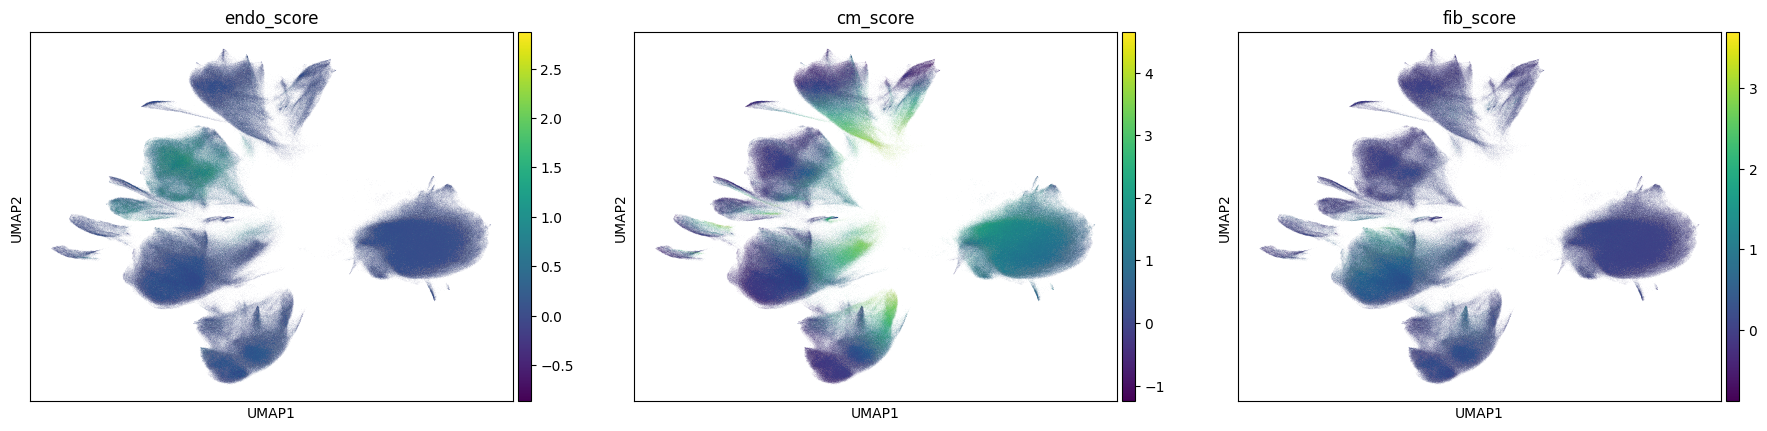

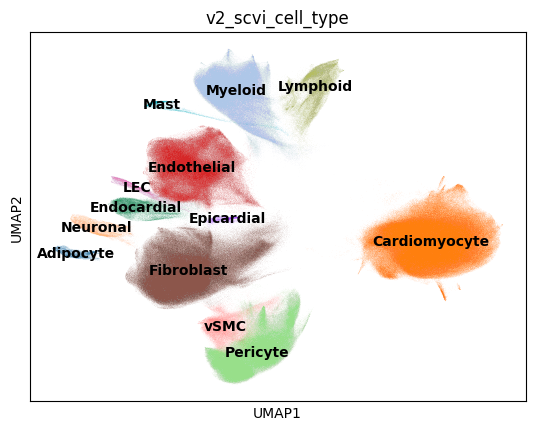

In [14]:
with plt.rc_context():
    sc.pl.umap(filt_adata, color = ["v2_scvi_cell_type"], legend_loc = "on data")
    plt.savefig(plots_dir + "original_UMAP_before_contamination_removal.pdf")

In [20]:
filt_adata.obs['barcode'] = filt_adata.obs['barcode'].astype(str)

In [21]:
del filt_adata.X
gc.collect()

15161

In [22]:
%%time
filt_adata.write("06A_filtered_adata.h5ad")

CPU times: user 6 μs, sys: 15 μs, total: 21 μs
Wall time: 42.7 μs
